# Graphical Exploratory Data Analysis (EDA)

Graphical EDA complements non-graphical methods by making distributions, patterns, and relationships visible.

## Overview
| | Methods |
|---|---|
| **Univariate** | line chart, box plot, histogram, QQ plot, bar chart, pie chart |
| **Multivariate** | scatter plot, bubble plot, scatter plot matrix, hexbin plot, correlation heatmap |

In [1]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')

# Load apartment data
df = pd.read_csv('../data/apartments_data_enriched_cleaned.csv')
print('Shape:', df.shape)
df.head(3)

Shape: (774, 17)


,Unnamed: 0,web-scraper-order,address_raw,lat,lon,bfs_number,bfs_name,rooms,area,luxurious,price,price_per_m2,pop,pop_dens,emp,frg_pct,mean_taxable_income
0,0,1693998201-1,"Neuhusstrasse 6, 8630 Rüti ZH, ZH",47.252171,8.845797,118,Rüti (ZH),3.0,49.0,0,1441.0,29.41,12286,1221.272366,5053.0,24.841283,65362.042683
1,1,1693998233-172,"Widacherstrasse 5, 8630 Rüti ZH, ZH",47.252087,8.854919,118,Rüti (ZH),3.0,111.0,0,2600.0,23.42,12286,1221.272366,5053.0,24.841283,65362.042683
2,2,1693998256-331,"Widenweg 14, 8630 Rüti ZH, ZH",47.253670,8.853993,118,Rüti (ZH),3.0,58.0,0,1490.0,25.69,12286,1221.272366,5053.0,24.841283,65362.042683


---
## Univariate Graphical EDA

### Line Chart

A line chart displays data points connected by lines. Commonly used for time series data.

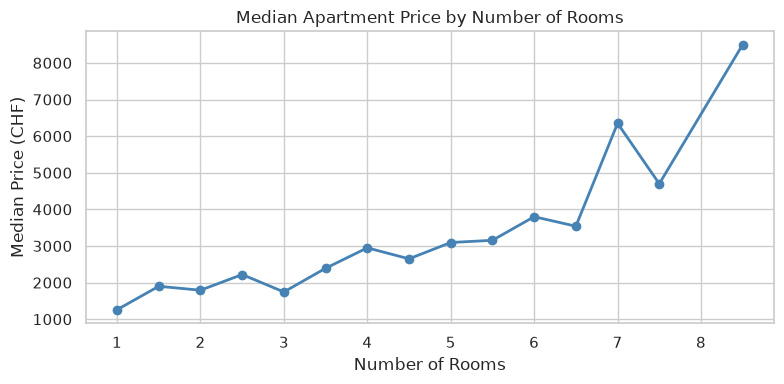

In [2]:
# Line chart: median apartment price per number of rooms
price_by_rooms = df.groupby('rooms')['price'].median().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(price_by_rooms.index, price_by_rooms.values, marker='o', linewidth=2, color='steelblue')
ax.set_xlabel('Number of Rooms')
ax.set_ylabel('Median Price (CHF)')
ax.set_title('Median Apartment Price by Number of Rooms')
plt.tight_layout()
plt.show()

### Box Plot

A box plot shows the distribution of a variable through its quartiles. The box represents the interquartile range (IQR = Q3 − Q1), the line inside the box is the median, and the whiskers extend to 1.5×IQR. Points beyond the whiskers are potential outliers.

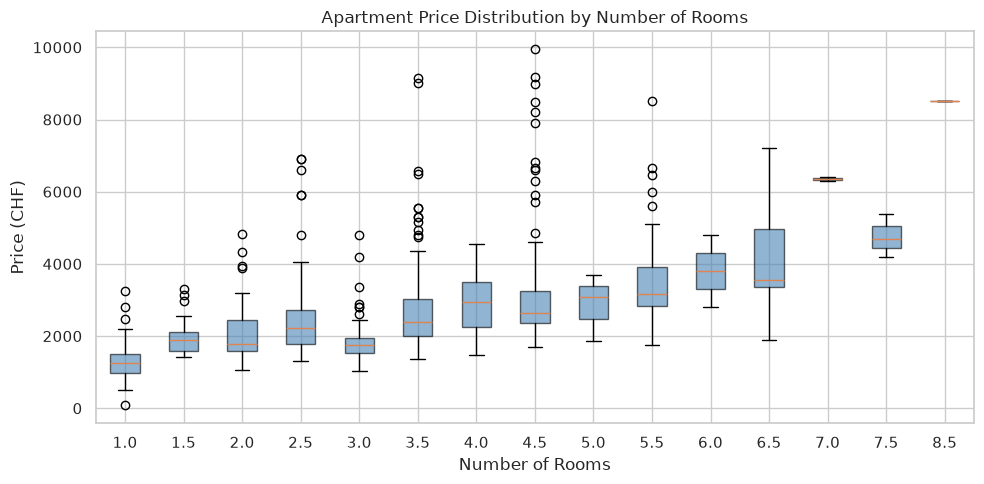

In [3]:
# Box plot: price distribution by number of rooms
fig, ax = plt.subplots(figsize=(10, 5))
rooms_sorted = sorted(df['rooms'].unique())
data_by_rooms = [df[df['rooms'] == r]['price'].dropna().values for r in rooms_sorted]
ax.boxplot(data_by_rooms, tick_labels=[str(r) for r in rooms_sorted], patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.6))
ax.set_xlabel('Number of Rooms')
ax.set_ylabel('Price (CHF)')
ax.set_title('Apartment Price Distribution by Number of Rooms')
plt.tight_layout()
plt.show()

### Histogram

A histogram shows the frequency distribution of a numerical variable by dividing the range into bins.

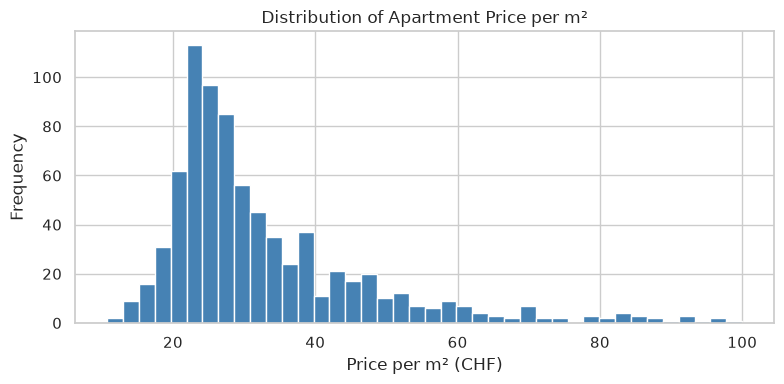

In [4]:
# Histogram: price per m²
df['price_per_m2'] = df['price'] / df['area']

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df['price_per_m2'].dropna(), bins=40, color='steelblue', edgecolor='white')
ax.set_xlabel('Price per m² (CHF)')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Apartment Price per m²')
plt.tight_layout()
plt.show()

### Quantile-Quantile (QQ) Plot

A QQ plot compares the quantiles of a variable against the quantiles of a theoretical distribution (usually normal). If the points fall on the diagonal line, the data is approximately normally distributed. Deviations reveal skewness or heavy tails.

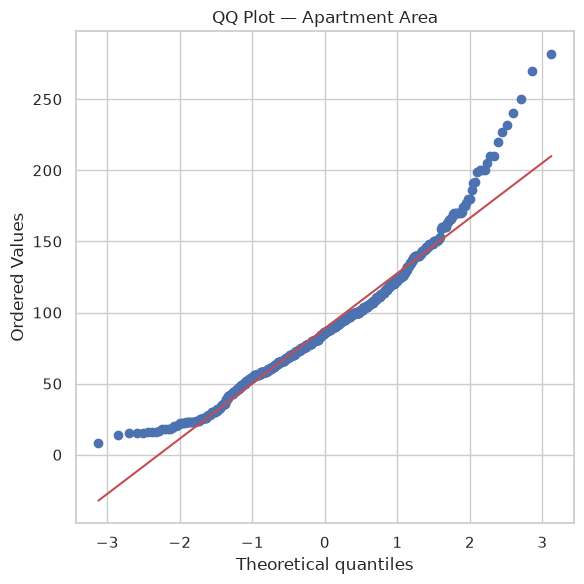

In [5]:
# QQ plot: apartment area
fig, ax = plt.subplots(figsize=(6, 6))
stats.probplot(df['area'].dropna(), dist='norm', plot=ax)
ax.set_title('QQ Plot — Apartment Area')
plt.tight_layout()
plt.show()

### Bar Chart

A bar chart displays categorical data with rectangular bars. Heights represent values (counts, means, etc.).

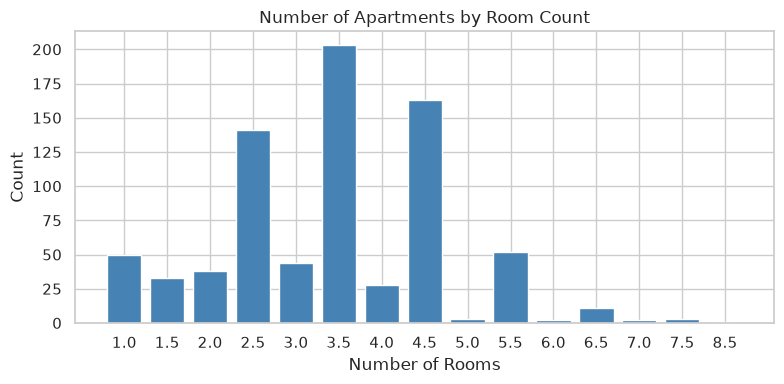

In [6]:
# Bar chart: count of apartments per number of rooms
room_counts = df['rooms'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(room_counts.index.astype(str), room_counts.values, color='steelblue', edgecolor='white')
ax.set_xlabel('Number of Rooms')
ax.set_ylabel('Count')
ax.set_title('Number of Apartments by Room Count')
plt.tight_layout()
plt.show()

### Pie Chart

A pie chart shows the proportional composition of categories. Use with care: angles and areas are harder to compare than lengths. For more than a few categories, prefer a bar chart (Wilke, 2019).

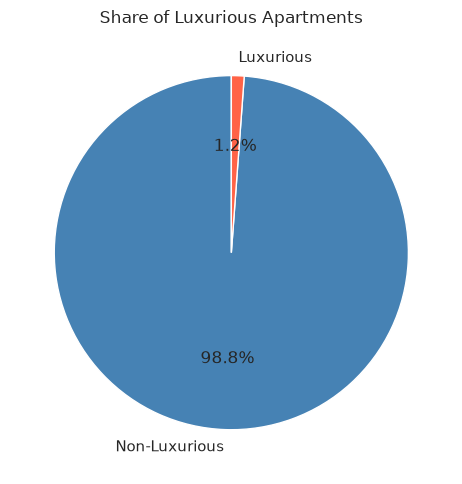

In [7]:
# Pie chart: luxurious vs. non-luxurious apartments
lux_counts = df['luxurious'].value_counts()

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(lux_counts.values, labels=['Non-Luxurious', 'Luxurious'],
       autopct='%1.1f%%', colors=['steelblue', 'tomato'], startangle=90)
ax.set_title('Share of Luxurious Apartments')
plt.tight_layout()
plt.show()

---
## Multivariate Graphical EDA

### Scatter Plot

A scatter plot shows the relationship between two numerical variables.

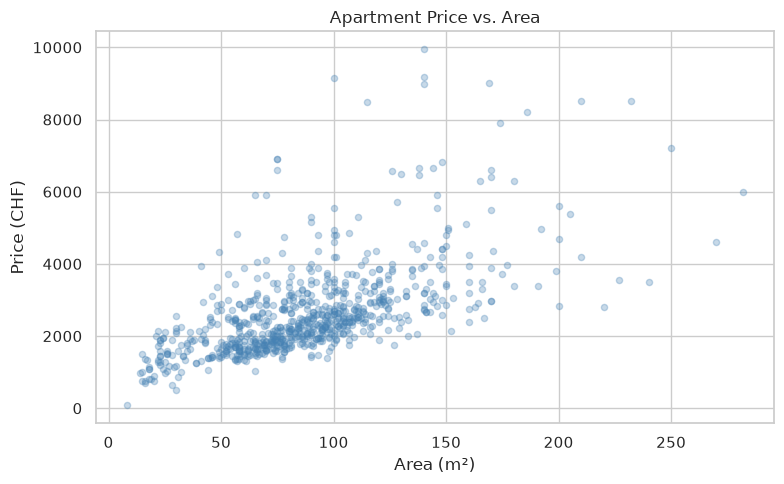

In [8]:
# Scatter plot: price vs. area
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df['area'], df['price'], alpha=0.3, color='steelblue', s=20)
ax.set_xlabel('Area (m²)')
ax.set_ylabel('Price (CHF)')
ax.set_title('Apartment Price vs. Area')
plt.tight_layout()
plt.show()

### Bubble Plot

A bubble plot extends a scatter plot by encoding a third (and optionally fourth) variable through the size and/or color of each point.

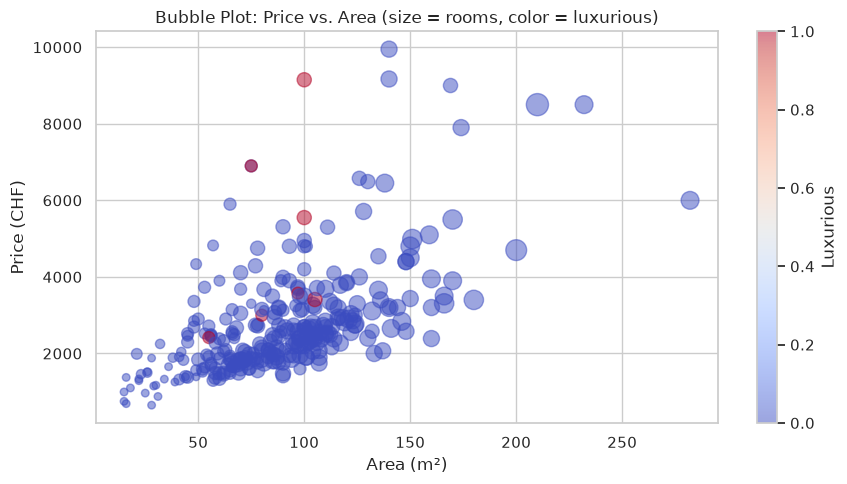

In [9]:
# Bubble plot: price vs. area, bubble size = rooms, color = luxurious
sample = df.dropna(subset=['price', 'area', 'rooms']).sample(300, random_state=42)

fig, ax = plt.subplots(figsize=(9, 5))
scatter = ax.scatter(
    sample['area'], sample['price'],
    s=sample['rooms'] * 30,
    c=sample['luxurious'],
    cmap='coolwarm', alpha=0.5
)
plt.colorbar(scatter, ax=ax, label='Luxurious')
ax.set_xlabel('Area (m²)')
ax.set_ylabel('Price (CHF)')
ax.set_title('Bubble Plot: Price vs. Area (size = rooms, color = luxurious)')
plt.tight_layout()
plt.show()

### Scatter Plot Matrix

A scatter plot matrix (pair plot) shows pairwise relationships between all combinations of selected variables.

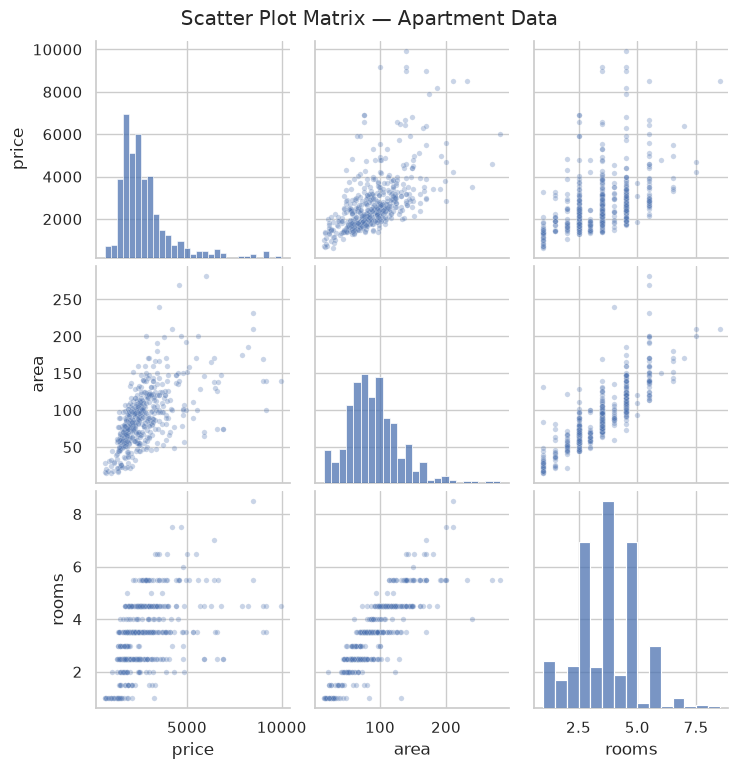

In [10]:
# Scatter plot matrix
num_cols = ['price', 'area', 'rooms']
sample = df[num_cols].dropna().sample(500, random_state=42)

fig = sns.pairplot(sample, diag_kind='hist', plot_kws={'alpha': 0.3, 's': 15})
fig.fig.suptitle('Scatter Plot Matrix — Apartment Data', y=1.02)
plt.show()

### Hexagonal Binning Plot

A hexbin plot is useful when overplotting makes scatter plots hard to read. It divides the space into hexagonal bins and colors each by the number of points inside.

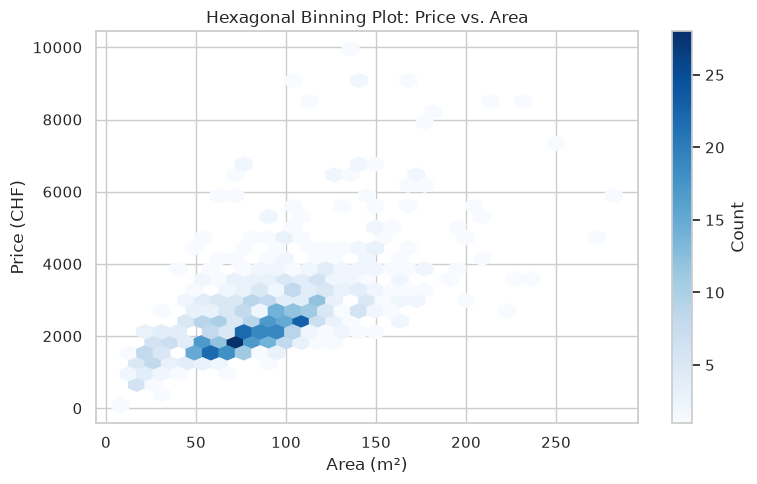

In [11]:
# Hexagonal binning plot: price vs. area
fig, ax = plt.subplots(figsize=(8, 5))
hb = ax.hexbin(df['area'].dropna(), df['price'].dropna(), gridsize=30, cmap='Blues', mincnt=1)
plt.colorbar(hb, ax=ax, label='Count')
ax.set_xlabel('Area (m²)')
ax.set_ylabel('Price (CHF)')
ax.set_title('Hexagonal Binning Plot: Price vs. Area')
plt.tight_layout()
plt.show()

### Correlation Heatmap

A correlation heatmap visualizes the correlation matrix using colors. Strong positive correlations are shown in one color, strong negative in another, making patterns immediately visible.

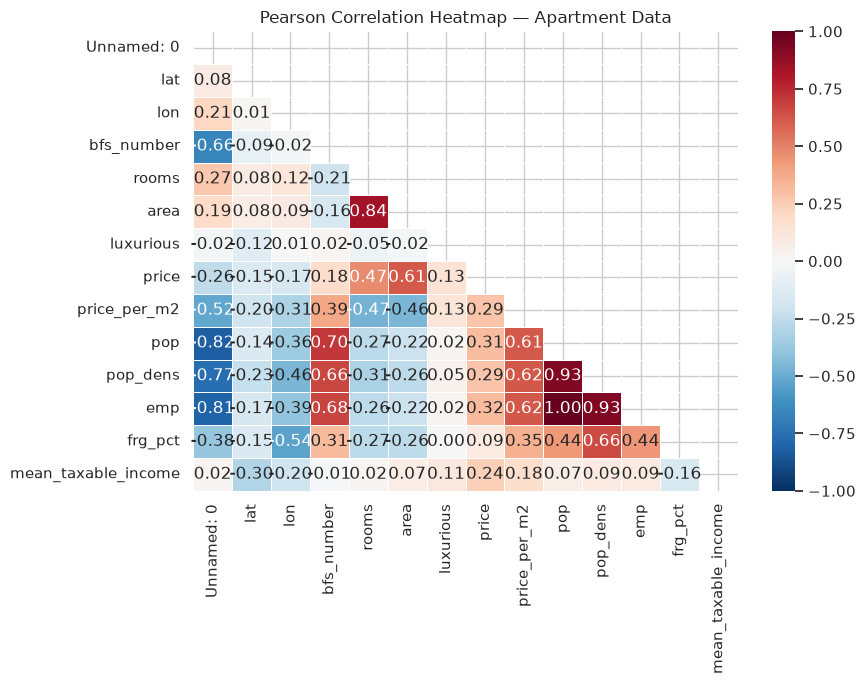

In [12]:
# Correlation heatmap
corr_matrix = df.corr(method='pearson', numeric_only=True)

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # show only lower triangle
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax
)
ax.set_title('Pearson Correlation Heatmap — Apartment Data')
plt.tight_layout()
plt.show()

## Jupyter notebook --footer info--
(please always provide this at the end of each notebook)

In [13]:
import os
import platform
import socket
from platform import python_version
from datetime import datetime

print('------------------------------------')
print(os.name.upper())
print(platform.system(), '|', platform.release())
print('Datetime:', datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print('Python Version:', python_version())
print('------------------------------------')

------------------------------------
POSIX
Linux | 6.8.0-1064-azure
Datetime: 2026-10-01 07:19:32
Python Version: 3.11.16
------------------------------------
